In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
df=pd.read_csv('/content/weatherHistory.csv')
df.head(10)

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
5,2006-04-01 05:00:00.000 +0200,Partly Cloudy,rain,9.222222,7.111111,0.85,13.9587,258.0,14.9569,0.0,1016.66,Partly cloudy throughout the day.
6,2006-04-01 06:00:00.000 +0200,Partly Cloudy,rain,7.733333,5.522222,0.95,12.3648,259.0,9.9820,0.0,1016.72,Partly cloudy throughout the day.
7,2006-04-01 07:00:00.000 +0200,Partly Cloudy,rain,8.772222,6.527778,0.89,14.1519,260.0,9.9820,0.0,1016.84,Partly cloudy throughout the day.
8,2006-04-01 08:00:00.000 +0200,Partly Cloudy,rain,10.822222,10.822222,0.82,11.3183,259.0,9.9820,0.0,1017.37,Partly cloudy throughout the day.
9,2006-04-01 09:00:00.000 +0200,Partly Cloudy,rain,13.772222,13.772222,0.72,12.5258,279.0,9.9820,0.0,1017.22,Partly cloudy throughout the day.


In [3]:
df.shape

(96453, 12)

In [4]:
df.isna().sum()

,0
Formatted Date,0
Summary,0
Precip Type,517
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0


In [5]:
df.dropna(inplace=True)

In [6]:
df.describe()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
count,95936.000000,95936.000000,95936.000000,95936.000000,95936.000000,95936.000000,95936.0,95936.000000
mean,11.940976,10.862531,0.734841,10.804936,187.518773,10.362402,0.0,1003.150038
std,9.570671,10.717812,0.195724,6.920727,107.385351,4.173780,0.0,117.276976
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.604167,2.276389,0.600000,5.796000,116.000000,8.372000,0.0,1011.890000
50%,12.033333,12.033333,0.780000,9.933700,180.000000,10.046400,0.0,1016.420000
75%,18.844444,18.844444,0.890000,14.135800,290.000000,14.812000,0.0,1021.050000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95936 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            95936 non-null  object 
 1   Summary                   95936 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           95936 non-null  float64
 4   Apparent Temperature (C)  95936 non-null  float64
 5   Humidity                  95936 non-null  float64
 6   Wind Speed (km/h)         95936 non-null  float64
 7   Wind Bearing (degrees)    95936 non-null  float64
 8   Visibility (km)           95936 non-null  float64
 9   Loud Cover                95936 non-null  float64
 10  Pressure (millibars)      95936 non-null  float64
 11  Daily Summary             95936 non-null  object 
dtypes: float64(8), object(4)
memory usage: 9.5+ MB


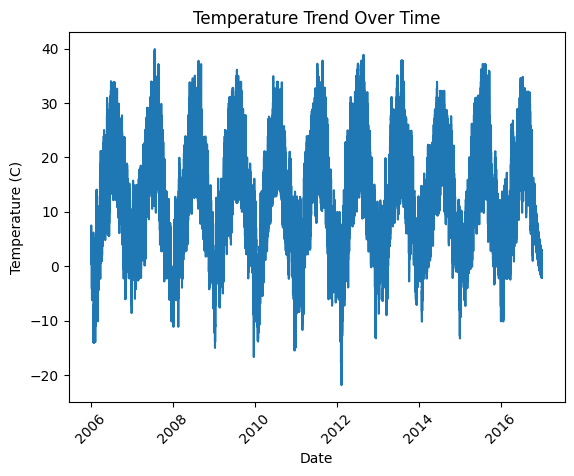

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert to datetime (replace column name if different)
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'])

# Sort by date
df = df.sort_values('Formatted Date')

# Plot
plt.figure()
plt.plot(df['Formatted Date'], df['Temperature (C)'])
plt.xlabel('Date')
plt.ylabel('Temperature (C)')
plt.title('Temperature Trend Over Time')
plt.xticks(rotation=45)
plt.show()

The temperature trend over time shows a clear cyclical pattern, indicating strong seasonal variations across the years. Temperatures peak during warmer months and drop significantly during colder periods, repeating consistently each year. Although there are short-term fluctuations and occasional extreme values, the overall seasonal structure remains stable. This pattern confirms that temperature data has strong temporal dependency, making it suitable for time-series modeling.


In [9]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
cols = ['Temperature (C)','Apparent Temperature (C)','Humidity','Wind Speed (km/h)','Wind Bearing (degrees)','Visibility (km)','Loud Cover','Pressure (millibars)']
df[cols] = scaler.fit_transform(df[cols])

In [10]:
from sklearn.preprocessing import LabelEncoder
cols = ['Summary', 'Precip Type', 'Daily Summary']
for col in cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [11]:
features = ['Temperature (C)', 'Humidity', 'Wind Speed (km/h)']
df = df.sort_values('Formatted Date')

In [12]:
sequence_length = 14
X = []
y = []

data = df[features].values

for i in range(len(data) - sequence_length):
    X.append(data[i:i+sequence_length])  # Past 14 days
    y.append(data[i+sequence_length][0])  # Next day's Temperature

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (95922, 14, 3)
y shape: (95922,)


In [13]:
train_size = int(0.7 * len(X))
val_size = int(0.15 * len(X))

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (67145, 14, 3)
Validation: (14388, 14, 3)
Test: (14389, 14, 3)


#RNN Model Development

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

sequence_length = X_train.shape[1]
num_features = X_train.shape[2]

model = Sequential([

    # Input + SimpleRNN layer
    SimpleRNN(64,
              activation='tanh',
              input_shape=(sequence_length, num_features)),

    # Optional Dropout
    Dropout(0.2),

    # Output layer (Regression)
    Dense(1, activation='linear')
])

model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417 (17.25 KB)

 Trainable params: 4,417 (17.25 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
input_shape=(sequence_length, num_features)

In [16]:
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

The training loss decreases sharply during the initial epochs, indicating that the model quickly learns important patterns from the data. After the first few epochs, both training and validation losses stabilize and remain relatively close to each other. The validation loss does not increase over time, which suggests that the model is not overfitting. Overall, the curves indicate stable learning and good generalization performance on unseen data.


#Model Evaluation & Forecasting

In [19]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 0.0156 - mae: 0.0755 - val_loss: 3.6187e-04 - val_mae: 0.0143
Epoch 2/100
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - loss: 0.0016 - mae: 0.0312 - val_loss: 3.2377e-04 - val_mae: 0.0139
Epoch 3/100
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 9.6754e-04 - mae: 0.0236 - val_loss: 3.6450e-04 - val_mae: 0.0152
Epoch 4/100
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 6.9042e-04 - mae: 0.0198 - val_loss: 2.8488e-04 - val_mae: 0.0130
Epoch 5/100
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 6.0965e-04 - mae: 0.0183 - val_loss: 2.7874e-04 - val_mae: 0.0127
Epoch 6/100
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 5.7284e-04 - mae: 0.0178 - val_loss: 2.6662e-04 - val_mae: 0.0124
Epoch 7/100
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 5.7192e-04 - mae: 0.0177 - val_loss: 2.9472e-04 - val_mae: 0.0135
Epoch 8/100
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 5.7066e-04 - mae: 0.0176 - val_los

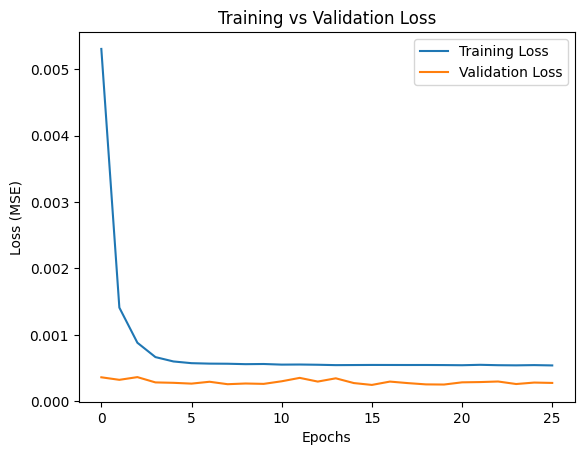

In [20]:


plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [21]:

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
y_pred = model.predict(X_test)
y_pred = y_pred.flatten()

450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [22]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

RMSE: 0.015456168807389451
MAE: 0.011172989794389692
R2 Score: 0.9893971105838968


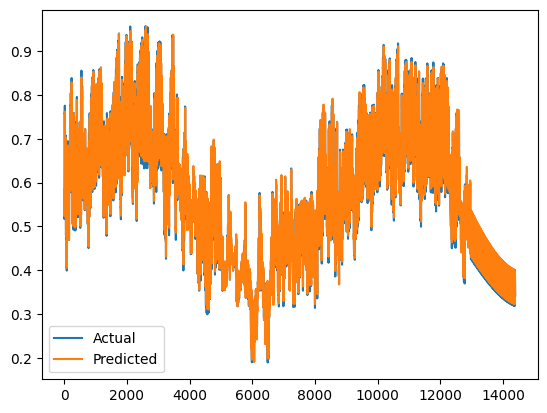

In [23]:
plt.figure()
plt.plot(y_test, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.show()

The plot compares the actual and predicted temperature values on the test dataset. The predicted values closely follow the overall trend and seasonal pattern of the actual temperatures, indicating that the SimpleRNN model has learned the temporal structure of the data. Although the predictions appear slightly smoother than the actual values, the model captures most of the fluctuations reasonably well. Overall, the model demonstrates good performance in forecasting temperature trends over time.
